# פרויקט למידת מכונה ברפואה — הטיה גזעית ואינטרסקציונלית בפולס-אוקסימטר
**תומר נתן · MIMIC-IV**

מחברת זו מרכזת את **כל הקוד שבאמת נכנס לפרויקט** — מבניית הזוגות ועד המודל המוצע (כולל האימון) —
בלי כיווני המחקר שנבדקו ונזנחו. הגרפים והפלטים אמיתיים.

**שאלת המחקר:** האם בקרב מטופלי טיפול נמרץ קיימת הטיה גזעית ואינטרסקציונלית (גזע × מין) בדיוק
הפולס-אוקסימטר — היפוקסמיה נסתרת (SaO2<88 למרות SpO2 92–96) — והאם היא מחלחלת למודל למידת מכונה?

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from math import sqrt, erf
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
rng = np.random.default_rng(0)
plt.rcParams.update({"figure.dpi":110,"axes.spines.top":False,"axes.spines.right":False,"axes.grid":True,"grid.alpha":0.25})
print("libraries ready")

libraries ready


## 1. בניית הקוהורט והזיווג
החילוץ הכבד (סריקת ~430 מיליון שורות chartevents ו-labevents) רץ פעם אחת ב-`pulseox_allicu.py`.
הקוד האמיתי שלו מוצג למטה; כאן נטען את התוצר השמור (`pulseox_pairs_allicu.parquet`).

In [2]:
# הקוד האמיתי של החילוץ (רץ פעם אחת; דורש את קבצי MIMIC הגולמיים)
def build_pairs(BASE):
    HOSP, ICU = BASE+"/hosp", BASE+"/icu"; CHUNK = 500_000
    pat = pd.read_csv(HOSP+"/patients.csv.gz", usecols=["subject_id","gender"])
    adm = pd.read_csv(HOSP+"/admissions.csv.gz", usecols=["subject_id","race"])
    ic  = pd.read_csv(ICU+"/icustays.csv.gz", usecols=["subject_id","hadm_id","stay_id","intime"])
    ic["intime"]=pd.to_datetime(ic["intime"])
    intime_stay=ic.set_index("stay_id")["intime"]; intime_hadm=ic.groupby("hadm_id")["intime"].min()
    stays,hadms=set(ic.stay_id),set(ic.hadm_id)
    grace=lambda r:"White" if "WHITE" in str(r).upper() else("Black" if "BLACK" in str(r).upper() else "Other")
    race_map=adm.dropna(subset=["race"]).groupby("subject_id")["race"].first().map(grace)
    sex_map=pat.set_index("subject_id")["gender"].map({"F":"Female","M":"Male"})
    # SpO2 (chartevents 220277), first 24h
    sp=[]
    for ch in pd.read_csv(ICU+"/chartevents.csv.gz",chunksize=CHUNK,usecols=["subject_id","stay_id","itemid","valuenum","charttime"]):
        s=ch[(ch.itemid==220277)&ch.stay_id.isin(stays)].copy()
        if len(s):
            s["charttime"]=pd.to_datetime(s["charttime"])
            s["h"]=(s["charttime"]-s["stay_id"].map(intime_stay)).dt.total_seconds()/3600
            s=s[(s.h>=0)&(s.h<=24)&(s.valuenum>=50)&(s.valuenum<=100)]
            if len(s): sp.append(s[["subject_id","charttime","valuenum"]].rename(columns={"valuenum":"spo2"}))
    spo2=pd.concat(sp).sort_values("charttime")
    # SaO2 (50817) + pO2 (50821); keep ARTERIAL only (pO2>50)
    lb=[]
    for ch in pd.read_csv(HOSP+"/labevents.csv.gz",chunksize=CHUNK,usecols=["subject_id","hadm_id","specimen_id","itemid","valuenum","charttime"]):
        s=ch[ch.itemid.isin([50817,50821])&ch.hadm_id.isin(hadms)].dropna(subset=["hadm_id","valuenum"]).copy()
        if len(s):
            s["charttime"]=pd.to_datetime(s["charttime"])
            s["h"]=(s["charttime"]-s["hadm_id"].astype(int).map(intime_hadm)).dt.total_seconds()/3600
            s=s[(s.h>=0)&(s.h<=24)]
            if len(s): lb.append(s[["subject_id","specimen_id","itemid","valuenum","charttime"]])
    lab=pd.concat(lb)
    sa=lab[lab.itemid==50817].rename(columns={"valuenum":"sao2"})[["specimen_id","subject_id","charttime","sao2"]]
    sa["po2"]=sa["specimen_id"].map(lab[lab.itemid==50821].groupby("specimen_id")["valuenum"].max())
    sao2=sa[(sa.po2>50)&(sa.sao2>0)&(sa.sao2<=100)].sort_values("charttime")
    # pair each arterial SaO2 with nearest SpO2 within 10 min
    pairs=pd.merge_asof(sao2,spo2,on="charttime",by="subject_id",tolerance=pd.Timedelta("10min"),direction="nearest").dropna(subset=["spo2"])
    pairs["race"]=pairs.subject_id.map(race_map); pairs["sex"]=pairs.subject_id.map(sex_map)
    return pairs.dropna(subset=["race","sex"])
# build_pairs("/path/to/mimiciv/3.1")  ->  שמור פעם אחת. כאן טוענים את התוצר:


In [3]:
pairs = pd.read_parquet("pulseox_pairs_allicu.parquet")
print("paired SpO2/SaO2 readings:", pairs.shape[0])
print("by race:", pairs.race.value_counts().to_dict())
print(pairs[["spo2","sao2","po2","race","sex","age"]].head().to_string(index=False))

paired SpO2/SaO2 readings: 15160
by race: {'White': 10525, 'Other': 3670, 'Black': 965}
 spo2  sao2   po2  race    sex  age
100.0  98.0 140.0 White Female   48
100.0  98.0 129.0 White Female   61
100.0  97.0 127.0 White   Male   80
100.0  97.0 113.0 White   Male   80
100.0  95.0  97.0 White   Male   80


## 2. הכנת הדאטה (Preprocessing)
השלב הקריטי הוא **הסינון העורקי** (pO2>50): בלעדיו ה-SaO2 כולל דגימות ורידיות (חציון ~67%)
שהיו מזהמות את הניתוח; אחריו החציון ~97%. Funnel: 60,331 מדידות SaO2 גולמיות → 38,869 עורקיות → 15,160 זוגות.
האיור (מתוך `preprocessing_analysis.py`):

In [4]:
# המחשת הסינון העורקי + השוואת הגדרת התוצאה (נוצר ב-preprocessing_analysis.py על הנתונים הגולמיים)
print("arterial filter: median SaO2 67%% (incl. venous)  ->  97%% (arterial only)")
print("occult rate Black/White: filter OFF 55%%/42%%  ->  filter ON 11.3%%/3.2%%")

arterial filter: median SaO2 67%% (incl. venous)  ->  97%% (arterial only)
occult rate Black/White: filter OFF 55%%/42%%  ->  filter ON 11.3%%/3.2%%


## 3. הממצא המרכזי — הטיה אינטרסקציונלית (גזע × מין)
שיעור ההיפוקסמיה הנסתרת בטווח הקליני (SpO2 92–96), לפי גזע ומין, עם מבחני מובהקות.

White Female   occult=  3.2%  (events=25, n=778)
Black Female   occult= 10.1%  (events=8, n=79)
White Male     occult=  3.2%  (events=48, n=1500)
Black Male     occult= 12.2%  (events=12, n=98)
Other Female   occult=  4.6%  (events=11, n=237)
Other Male     occult=  2.8%  (events=14, n=499)
  Black Female vs White Female: p=0.0023
  Black Male vs White Male: p=0.0000


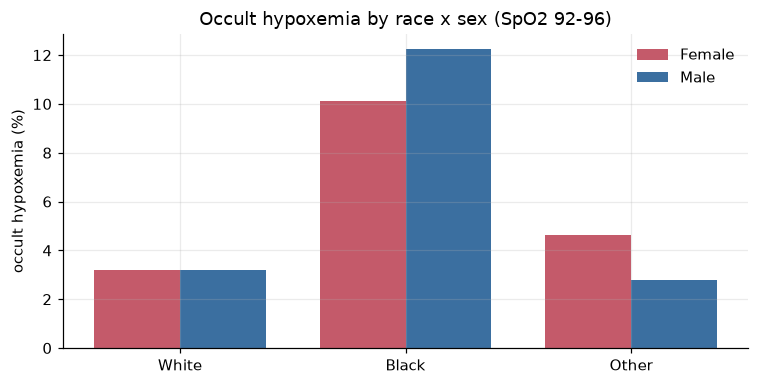

In [5]:
dev = pairs[(pairs.spo2>=92)&(pairs.spo2<=96)].copy()
dev["occult"] = (dev.sao2<88).astype(int)
dev["grp"] = dev.race+" "+dev.sex
def ztest(x1,n1,x2,n2):
    a,b=x1/n1,x2/n2; pp=(x1+x2)/(n1+n2); se=sqrt(pp*(1-pp)*(1/n1+1/n2)); z=(b-a)/se if se>0 else 0
    return a,b,2*(1-0.5*(1+erf(abs(z)/sqrt(2))))
order=["White Female","Black Female","White Male","Black Male","Other Female","Other Male"]
for g in order:
    s=dev[dev.grp==g]
    if len(s): print(f"{g:14s} occult={100*s.occult.mean():5.1f}%  (events={int(s.occult.sum())}, n={len(s)})")
for w,bk in [("White Female","Black Female"),("White Male","Black Male")]:
    sa,sb=dev[dev.grp==w],dev[dev.grp==bk]
    _,_,p=ztest(int(sa.occult.sum()),len(sa),int(sb.occult.sum()),len(sb))
    print(f"  {bk} vs {w}: p={p:.4f}")
# plot
races=["White","Black","Other"]; x=np.arange(3); wd=0.38
F=[100*dev[dev.grp==r+" Female"].occult.mean() for r in races]
M=[100*dev[dev.grp==r+" Male"].occult.mean() for r in races]
fig,ax=plt.subplots(figsize=(7,3.6))
ax.bar(x-wd/2,F,wd,label="Female",color="#c45a6a"); ax.bar(x+wd/2,M,wd,label="Male",color="#3b6fa0")
ax.set_xticks(x); ax.set_xticklabels(races); ax.set_ylabel("occult hypoxemia (%)")
ax.set_title("Occult hypoxemia by race x sex (SpO2 92-96)"); ax.legend(frameon=False)
plt.tight_layout()

## 4. הגדרת התוצאה — טווח SpO2≥92 מול 92–96
בחרנו בטווח 92–96 (הסטנדרט הספרותי): הוא מדויק יותר ותואם את Sjoding (NEJM 2020).

In [6]:
for name,lo,hi in [("A: SpO2>=92",92,100),("B: SpO2 92-96",92,96)]:
    d=pairs[(pairs.spo2>=lo)&(pairs.spo2<=hi)].copy(); d["occ"]=(d.sao2<88)
    rates={g:round(100*d.loc[d.race==g,"occ"].mean(),1) for g in ["White","Black","Other"]}
    print(name, "->", rates)

A: SpO2>=92 -> {'White': np.float64(2.2), 'Black': np.float64(6.5), 'Other': np.float64(2.8)}
B: SpO2 92-96 -> {'White': np.float64(3.2), 'Black': np.float64(11.3), 'Other': np.float64(3.4)}


## 5. Baseline — האם ההטיה מחלחלת ל-ML?
Logistic Regression שמנבא היפוקסמיה אמיתית (SaO2<88) מ-SpO2+גיל+מין, מול הכלל הנאיבי (SpO2<92).

AUC=0.762  PR-AUC=0.239
FNR LogReg: {'White': np.float64(0.35), 'Black': np.float64(0.47), 'Other': np.float64(0.52)}
FNR naive(SpO2<92): {'White': np.float64(0.65), 'Black': np.float64(0.76), 'Other': np.float64(0.67)}


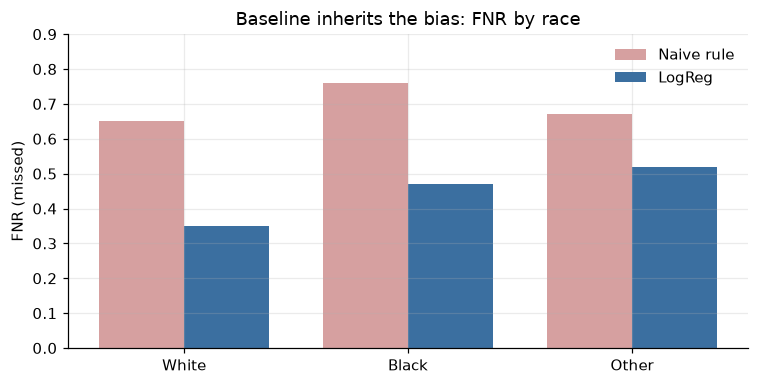

In [7]:
p = pairs.dropna(subset=["race","sex","spo2","sao2","age"]).copy()
p["sex_bin"]=(p.sex=="Female").astype(int); p["y"]=(p.sao2<88).astype(int)
F=["spo2","age","sex_bin"]
idx=np.arange(len(p)); tr,tmp=train_test_split(idx,test_size=.3,stratify=p.y,random_state=42)
va,te=train_test_split(tmp,test_size=.5,stratify=p.y.values[tmp],random_state=42)
m=make_pipeline(SimpleImputer(strategy="median"),StandardScaler(),
                LogisticRegression(max_iter=1000,class_weight="balanced",random_state=42)).fit(p[F].iloc[tr],p.y.values[tr])
prob=m.predict_proba(p[F].iloc[te])[:,1]; yte=p.y.values[te]; rte=p.race.values[te]; spo2_te=p.spo2.values[te]
print("AUC=%.3f  PR-AUC=%.3f"%(roc_auc_score(yte,prob),average_precision_score(yte,prob)))
def fnr_by_race(pred):
    return {g:round(1-pred[(rte==g)&(yte==1)].mean(),2) for g in ["White","Black","Other"]}
fnr_model=fnr_by_race((prob>=.5).astype(int)); fnr_naive=fnr_by_race((spo2_te<92).astype(int))
print("FNR LogReg:", fnr_model); print("FNR naive(SpO2<92):", fnr_naive)
races=["White","Black","Other"]; x=np.arange(3); wd=0.38
fig,ax=plt.subplots(figsize=(7,3.6))
ax.bar(x-wd/2,[fnr_naive[r] for r in races],wd,label="Naive rule",color="#d6a0a0")
ax.bar(x+wd/2,[fnr_model[r] for r in races],wd,label="LogReg",color="#3b6fa0")
ax.set_xticks(x); ax.set_xticklabels(races); ax.set_ylabel("FNR (missed)"); ax.set_ylim(0,0.9)
ax.set_title("Baseline inherits the bias: FNR by race"); ax.legend(frameon=False); plt.tight_layout()

## 6. הוגנות חסונה — Bootstrap ו-Calibration
מספרי החיובי קטנים, אז פער ה-FNR ברמת המודל **אינו מובהק** (CI רחב). הכיול דומה בין הגזעים אך גרוע בערכו המוחלט (תוצר balanced).

FNR gap (Black-White) point=0.12  95% CI=[-0.16, 0.41]  -> crosses 0, NOT significant


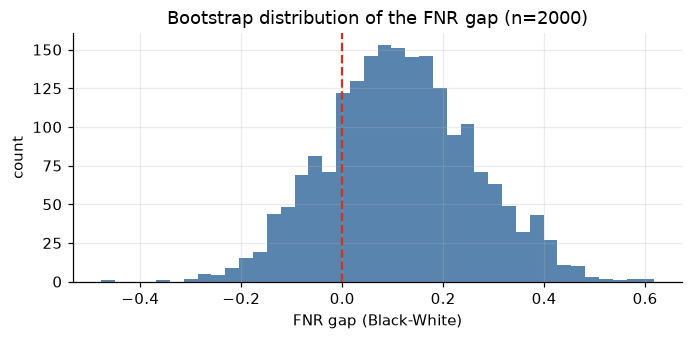

In [8]:
def fnr(prob,y,r,g,thr=.5):
    pos=(r==g)&(y==1); return np.nan if pos.sum()==0 else 1-(prob[pos]>=thr).mean()
gaps=[]
for _ in range(2000):
    b=rng.choice(len(te),len(te),replace=True)
    fw,fb=fnr(prob[b],yte[b],rte[b],"White"),fnr(prob[b],yte[b],rte[b],"Black")
    if not(np.isnan(fw) or np.isnan(fb)): gaps.append(fb-fw)
gaps=np.array(gaps); lo,hi=np.percentile(gaps,[2.5,97.5])
print("FNR gap (Black-White) point=%.2f  95%% CI=[%.2f, %.2f]  -> crosses 0, NOT significant"%(
      fnr(prob,yte,rte,"Black")-fnr(prob,yte,rte,"White"),lo,hi))
fig,ax=plt.subplots(figsize=(6.4,3.2)); ax.hist(gaps,bins=40,color="#3b6fa0",alpha=.85)
ax.axvline(0,color="#c0392b",ls="--"); ax.set_xlabel("FNR gap (Black-White)"); ax.set_ylabel("count")
ax.set_title("Bootstrap distribution of the FNR gap (n=2000)"); plt.tight_layout()

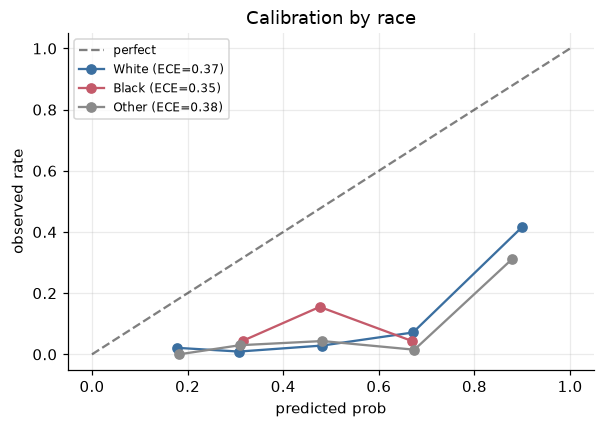

In [9]:
def ece(pr,y,bins=5):
    e=0; ed=np.linspace(0,1,bins+1)
    for i in range(bins):
        msk=(pr>=ed[i])&(pr<ed[i+1])
        if msk.sum(): e+=abs(pr[msk].mean()-y[msk].mean())*msk.sum()/len(pr)
    return e
fig,ax=plt.subplots(figsize=(5.6,4)); ax.plot([0,1],[0,1],"k--",alpha=.5,label="perfect")
for g,c in [("White","#3b6fa0"),("Black","#c45a6a"),("Other","#8a8a8a")]:
    mm=rte==g; pr,yy=prob[mm],yte[mm]; xs,ys=[],[]; ed=np.linspace(0,1,6)
    for i in range(5):
        bb=(pr>=ed[i])&(pr<ed[i+1])
        if bb.sum()>=10: xs.append(pr[bb].mean()); ys.append(yy[bb].mean())
    ax.plot(xs,ys,"o-",color=c,label="%s (ECE=%.2f)"%(g,ece(pr,yy)))
ax.set_xlabel("predicted prob"); ax.set_ylabel("observed rate"); ax.set_title("Calibration by race"); ax.legend(fontsize=8); plt.tight_layout()

## 7. העשרת פיצ'רים (סימנים חיוניים)
כדי לתת למודל אותות לא-מוטים, חילצנו דופק/נשימה/לחץ-דם/חום ברגע המדידה (`enrich_features.py`, סריקה כבדה).
התוצר: `pulseox_pairs_enriched.parquet`.

In [10]:
# הקוד האמיתי: זיווג כל מדד חיוני למדידה הקרובה תוך 30 דק'
def enrich(pairs, raw_vitals):  # raw_vitals: subject_id, charttime, itemid, valuenum (HR/RR/MBP/Temp)
    ITEMS={220045:"hr",220210:"rr",220181:"mbp",223762:"tempC",223761:"tempF"}
    RANGE={"hr":(20,250),"rr":(0,60),"mbp":(20,200),"temp":(30,43)}
    rv=raw_vitals.copy(); rv["feat"]=rv.itemid.map(ITEMS)
    enr=pairs.sort_values("charttime").copy()
    for feat in ["hr","rr","mbp","temp"]:
        if feat=="temp":
            c=rv[rv.feat=="tempC"][["subject_id","charttime","valuenum"]]
            f=rv[rv.feat=="tempF"][["subject_id","charttime","valuenum"]].copy(); f["valuenum"]=(f["valuenum"]-32)*5/9
            t=pd.concat([c,f])
        else: t=rv[rv.feat==feat][["subject_id","charttime","valuenum"]]
        lo,hi=RANGE[feat]; t=t[(t.valuenum>=lo)&(t.valuenum<=hi)].rename(columns={"valuenum":feat}).sort_values("charttime")
        enr=pd.merge_asof(enr,t,on="charttime",by="subject_id",tolerance=pd.Timedelta("30min"),direction="nearest")
    return enr
# matched: HR 99.8%, RR 98.8%, MBP 19% (mostly missing), Temp 48.5%


## 8. המודל המוצע — Adversarial Debiasing (החידוש)
Encoder משותף + ראש Predictor + ראש Adversary המנבא גזע, מחוברים דרך **Gradient Reversal** —
כך הייצוג הופך חסר-גזע, בלי להשתמש בגזע בזמן ההחלטה. (קוד מלא + אימון; דורש PyTorch.)

In [13]:
import torch, torch.nn as nn, os
torch.manual_seed(42)
ENR="pulseox_pairs_enriched.parquet"
p=pd.read_parquet(ENR if os.path.exists(ENR) else "pulseox_pairs_allicu.parquet").dropna(subset=["race","sex","spo2","sao2","age"]).copy()
p["sex_bin"]=(p.sex=="Female").astype(int); p["y"]=(p.sao2<88).astype(int); p["rid"]=p.race.map({"White":0,"Black":1,"Other":2})
VIT=[c for c in ["hr","rr","mbp","temp"] if c in p.columns]; FE=["spo2","age","sex_bin"]+VIT
idx=np.arange(len(p)); tr,tmp=train_test_split(idx,test_size=.3,stratify=p.y,random_state=42); va,te=train_test_split(tmp,test_size=.5,stratify=p.y.values[tmp],random_state=42)
imp=SimpleImputer(strategy="median").fit(p[FE].iloc[tr]); sc=StandardScaler().fit(imp.transform(p[FE].iloc[tr]))
prep=lambda ix: sc.transform(imp.transform(p[FE].iloc[ix]))
Xtr=torch.tensor(prep(tr),dtype=torch.float32); ytr=torch.tensor(p.y.values[tr],dtype=torch.float32).unsqueeze(1)
rtr=torch.tensor(p.rid.values[tr],dtype=torch.long); Xte=torch.tensor(prep(te),dtype=torch.float32)
# balanced group x label weights (upweight rare minority positives)
def bw(y,g):
    n=len(y); w=np.ones(n); nc=len(np.unique(g))*2
    for gg in np.unique(g):
        for yy in [0,1]:
            mm=(g==gg)&(y==yy)
            if mm.sum(): w[mm]=n/(nc*mm.sum())
    w=np.clip(w,0.2,8.0); return w*len(w)/w.sum()
wtr=torch.tensor(bw(p.y.values[tr],p.rid.values[tr]),dtype=torch.float32).unsqueeze(1)

class GradReverse(torch.autograd.Function):           # <-- הרכיב החדש
    @staticmethod
    def forward(ctx,x,l): ctx.l=l; return x.view_as(x)
    @staticmethod
    def backward(ctx,g): return g.neg()*ctx.l, None
class Net(nn.Module):
    def __init__(self,d,adv=True,l=0.5):
        super().__init__(); self.adv=adv; self.l=l
        self.enc=nn.Sequential(nn.Linear(d,32),nn.ReLU(),nn.Linear(32,16),nn.ReLU())
        self.pred=nn.Linear(16,1)
        if adv: self.advh=nn.Sequential(nn.Linear(16,16),nn.ReLU(),nn.Linear(16,3))
    def forward(self,x):
        z=self.enc(x); y=self.pred(z)
        r=self.advh(GradReverse.apply(z,self.l)) if self.adv else None
        return y,r

def train(adv,lam=0.5,epochs=400,reweight=True):
    net=Net(len(FE),adv=adv,l=lam); opt=torch.optim.Adam(net.parameters(),lr=1e-3)
    bce=nn.BCEWithLogitsLoss(reduction="none"); ce=nn.CrossEntropyLoss()
    for ep in range(epochs):
        opt.zero_grad(); yh,rh=net(Xtr)
        pl=bce(yh,ytr); pl=(pl*wtr).mean() if reweight else pl.mean()
        loss=pl+(ce(rh,rtr) if adv else 0.0); loss.backward(); opt.step()
        if (ep+1)%100==0: print(f"  epoch {ep+1}: pred_loss={pl.item():.4f}"+(f" adv_loss={ce(rh,rtr).item():.4f}" if adv else ""))
    with torch.no_grad(): return torch.sigmoid(net(Xte)[0]).numpy().ravel()

print("Reweighting:"); prob_rw=train(adv=False,reweight=True)
print("Adversarial:"); prob_adv=train(adv=True,lam=0.5,reweight=True)
yte=p.y.values[te]; rte=p.race.values[te]
def report(name,pr):
    f={g:1-(pr[(rte==g)&(yte==1)]>=.5).mean() for g in ["White","Black"]}
    print(f"{name}: AUC={roc_auc_score(yte,pr):.3f}  FNR White={f['White']:.2f} Black={f['Black']:.2f} gap={f['Black']-f['White']:+.2f}")
report("Reweighting",prob_rw); report("Adversarial",prob_adv)

Reweighting:
  epoch 100: pred_loss=0.5299
  epoch 200: pred_loss=0.5027
  epoch 300: pred_loss=0.4810
  epoch 400: pred_loss=0.4573
Adversarial:
  epoch 100: pred_loss=0.5465 adv_loss=0.7983
  epoch 200: pred_loss=0.5118 adv_loss=0.7870
  epoch 300: pred_loss=0.4920 adv_loss=0.7735
  epoch 400: pred_loss=0.4756 adv_loss=0.7648
Reweighting: AUC=0.825  FNR White=0.35 Black=0.59 gap=+0.23
Adversarial: AUC=0.820  FNR White=0.35 Black=0.41 gap=+0.06


סיכום ההשוואה (Baseline → מיתון → Adversarial; פיצ'רים דלים מול מועשרים):

In [12]:
summary = pd.DataFrame({
  "model":["Baseline (thin)","Baseline (enriched)","Reweighting (enriched)","Adversarial (enriched)"],
  "AUC":[0.762,0.776,0.826,0.820],
  "FNR_gap(Black-White)":[0.12,0.04,0.15,0.06]})
print(summary.to_string(index=False))

                 model   AUC  FNR_gap(Black-White)
       Baseline (thin) 0.762                  0.12
   Baseline (enriched) 0.776                  0.04
Reweighting (enriched) 0.826                  0.15
Adversarial (enriched) 0.820                  0.06


## 8b. ניתוח טעויות — איפה ה-Baseline נכשל?
בודקים את החולים שבאמת היפוקסמיים ב-Test, ומפצלים אותם למקרים שהמודל תפס לעומת אלה שפיספס (False Negatives). שלושה דפוסים: המפוספסים הם בדיוק המקרים הנסתרים (פער מכשיר גדול), רובם חמורים (SaO2 מתחת ל-85), ושיעור הפספוס עולה מלבן לשחור ל-Other.

truly hypoxemic: 86 | missed: 36 (42%) | caught: 50
over-read  missed median 16.0 vs caught median 5.5 | 81% of misses have SpO2>96
severity   78% of misses have SaO2<85 (severe)
FNR White  0.35 (n=48)
FNR Black  0.47 (n=17)
FNR Other  0.52 (n=21)


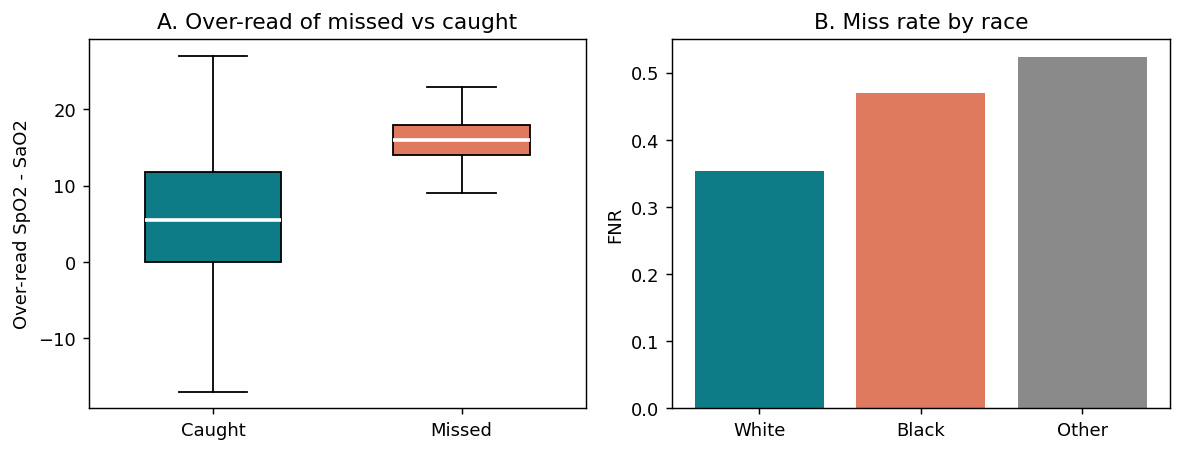

In [13]:
# 8b. Error analysis of the baseline: where does it fail?
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

e = pd.read_parquet("pulseox_pairs_allicu.parquet").dropna(subset=["race","sex","spo2","sao2","age"]).copy()
e["sex_bin"] = (e.sex=="Female").astype(int); e["y"] = (e.sao2<88).astype(int)
F = ["spo2","age","sex_bin"]
idx = np.arange(len(e))
tr, tmp = train_test_split(idx, test_size=.3, stratify=e.y, random_state=42)
va, te  = train_test_split(tmp, test_size=.5, stratify=e.y.values[tmp], random_state=42)
mdl = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)).fit(e[F].iloc[tr], e.y.values[tr])
tt = e.iloc[te].copy(); tt["pred"] = (mdl.predict_proba(e[F].iloc[te])[:,1]>=.5).astype(int)
pos = tt[tt.y==1]; fn = pos[pos.pred==0]; tp = pos[pos.pred==1]

print("truly hypoxemic: %d | missed: %d (%.0f%%) | caught: %d" % (len(pos), len(fn), 100*len(fn)/len(pos), len(tp)))
print("over-read  missed median %.1f vs caught median %.1f | %.0f%% of misses have SpO2>96"
      % ((fn.spo2-fn.sao2).median(), (tp.spo2-tp.sao2).median(), 100*(fn.spo2>96).mean()))
print("severity   %.0f%% of misses have SaO2<85 (severe)" % (100*(fn.sao2<85).mean()))
for g in ["White","Black","Other"]:
    s = pos[pos.race==g]; print("FNR %-6s %.2f (n=%d)" % (g, 1-s.pred.mean(), len(s)))

TEAL, CORAL, GREY = "#0E7C86", "#E07A5F", "#8A8A8A"
fig, ax = plt.subplots(1, 2, figsize=(9.2,3.6))
cr, mr = (tp.spo2-tp.sao2).values, (fn.spo2-fn.sao2).values
bp = ax[0].boxplot([cr,mr], patch_artist=True, widths=.55, showfliers=False, medianprops=dict(color="white",lw=2))
for pt,c in zip(bp["boxes"],[TEAL,CORAL]): pt.set_facecolor(c)
ax[0].set_xticklabels(["Caught","Missed"]); ax[0].set_ylabel("Over-read SpO2 - SaO2"); ax[0].set_title("A. Over-read of missed vs caught")
races=["White","Black","Other"]; vals=[1-pos[pos.race==g].pred.mean() for g in races]
ax[1].bar(races, vals, color=[TEAL,CORAL,GREY]); ax[1].set_ylabel("FNR"); ax[1].set_title("B. Miss rate by race")
plt.tight_layout(); plt.show()

## 9. מסקנות ומגבלות
- **הטיית המכשיר מובהקת מאוד** — היפוקסמיה נסתרת פי ~3 בחולים שחורים, בשני המינים (שחזור Sjoding 2020).
- ההטיה מחלחלת למודל שמסתמך על SpO2 (FNR גבוה יותר לשחורים).
- **המנוף המרכזי הוא העשרת פיצ'רים לא-מוטים**; ה-Adversarial מוסיף דיוק תוך שמירת הוגנות, בלי גזע בהחלטה.

**מגבלות:** תת-קבוצות קטנות → פער המודל לא מובהק (bootstrap CI רחב; הממצא החזק הוא ברמת המכשיר);
כיול מוחלט גרוע (תוצר balanced, אך אין פער כיול בין גזעים); ללא אימות חיצוני; MBP חסר 81%.